# Notebook 03 - Statistical Inference Layer

---

### Informasi Anggota
* **Nama**: Michelle Fiorentina Wong
* **NIM**: 1519625024
* **Peran**: Inference Analyst

---

# Tanggung Jawab 
Notebook ini menggunakan hasil estimasi parameter dari Notebook B (Estimator) untuk menghitung : 

1. Confidence Interval Mean
2. Confidence Interval Bernoulli
3. Confidence Interval Poisson
4. Bayesian Credible Interval


### Research Questions Addressed:
1. (Confidence Interval Mean):** Berapa estimasi rata-rata tingkat keberhasilan pull request (PR) yang di-merge pada repositori yang dianalisis, dan seberapa besar ketidakpastian estimasi tersebut?
2. (Bayesian Credible Interval):** Berdasarkan data yang diamati dan pendekatan Bayesian, dalam rentang berapa probabilitas sebenarnya sebuah pull request akan berhasil di-merge?


## AI Usage Disclosure

**Member:** Michelle Fiorentina Wong – Inference Analyst (Member C) | **Tools used:** ChatGPT, Claude

| Task | Tool | Prompt summary | Output modified? |
| :--- | :--- | :--- | :--- |
| Memperbaiki kesalahan dalam pembuatan notebook terkait penggunaan sintaks dalam penulisan markdown | Claude | "Apa yang salah dari dan seharusnya ditulis pada bagian penulisan markdown untuk notebook" | Yes - memahami tanda yang salah dan memperbaikinya secara manual |
| Meminta saran apakah visualisasi yang dipilih (grafik atau kurva) yang sesuai dengan karakteristik data | Chat GPT | Untuk pembuatan visualisasi data dalam inference analisis apa saja yang perlu untuk ditampilkan | Yes - Memilih beberapa kurva dan grafik yang disarankan dengan mencocokan pada data |
| Debugging dalam masalah menyatukan data dari notebook estimator | Claude | Berikan penjelasan dan tanda kesalahan dalam kode tersebut | Yes - Memperbaiki dengan panduan atau langkah AI secara manual |

**Written entirely without AI:** Pembuatan Visualisasi data dan perhitungan convidence interval (Mean, Bernoulli, Poisson, Bayesian Credible Interval) dan Kesimpulan. 

In [27]:
import numpy as np
import pandas as pd
from scipy.stats import norm, beta, chi2

def confidence_interval(theta_hat, sigma, n, confidence=0.95):
    z = norm.ppf((1 + confidence) / 2)

    margin_error = z * sigma / np.sqrt(n)

    lower = theta_hat - margin_error
    upper = theta_hat + margin_error

    return lower, upper


def ci_bernoulli(k, n, confidence=0.95):
    p_hat = k / n

    z = norm.ppf((1 + confidence) / 2)

    se = np.sqrt(p_hat * (1 - p_hat) / n)

    lower = p_hat - z * se
    upper = p_hat + z * se

    return lower, upper


def ci_poisson(data, confidence=0.95):
    data = np.asarray(data)

    n = len(data)
    total = np.sum(data)

    alpha = 1 - confidence

    lower = chi2.ppf(alpha / 2, 2 * total) / (2 * n)
    upper = chi2.ppf(1 - alpha / 2, 2 * (total + 1)) / (2 * n)

    return lower, upper


def credible_interval(alpha, beta_param, confidence=0.95):
    lower_q = (1 - confidence) / 2
    upper_q = 1 - lower_q

    lower = beta.ppf(lower_q, alpha, beta_param)
    upper = beta.ppf(upper_q, alpha, beta_param)

    return lower, upper

In [28]:
# Data dari hasil estimator atau Notebook B

# Data Bernoulli

data_pr_biner = np.array([1] * 2287 + [0] * 941)

# Data Poisson

data_bug_count = np.array([
    86,79,70,54,41,57,70,60,60,60,44,52,
    71,66,62,52,47,45,47,33,71,65,49,64,
    80,52,53,56,52,63,62,57,53,67,43,44,
    34,38,33,41,35,40,37,43,38,37,34,38,
    45,40,41,50,48,43,41,46,47,35,44,42
])

# Output Estimator (sesuai Notebook B)

n_samples = len(data_pr_biner)

k_merged = int(np.sum(data_pr_biner))
m_rejected = int(n_samples - k_merged)

theta_hat = np.mean(data_pr_biner)
lambda_hat = np.mean(data_bug_count)

alpha_post = k_merged + 1
beta_post = m_rejected + 1

sigma = np.std(data_pr_biner, ddof=1)

In [29]:
# Confidence Interval untuk mean
ci_mean = confidence_interval(theta_hat, sigma, n_samples)

print("=== Confidence Interval Mean ===")
print(f"Theta Hat : {theta_hat:.4f}")
print(f"95% CI    : ({ci_mean[0]:.4f}, {ci_mean[1]:.4f})")

=== Confidence Interval Mean ===
Theta Hat : 0.7085
95% CI    : (0.6928, 0.7242)


In [30]:
# Confidence Interval untuk proporsi Bernoulli
ci_bernoulli_result = ci_bernoulli(k_merged, n_samples)

print("\n=== Confidence Interval Proporsi Bernoulli ===")
print(f"p_hat      : {theta_hat:.4f}")
print(f"95% CI     : ({ci_bernoulli_result[0]:.4f}, {ci_bernoulli_result[1]:.4f})")


=== Confidence Interval Proporsi Bernoulli ===
p_hat      : 0.7085
95% CI     : (0.6928, 0.7242)


In [31]:
# Confidence Interval Poisson
ci_pois = ci_poisson(
    data_bug_count
)

print("=== Confidence Interval Poisson ===")
print(f"Lambda Hat : {lambda_hat:.4f}")
print(f"95% CI     : ({ci_pois[0]:.4f}, {ci_pois[1]:.4f})")

=== Confidence Interval Poisson ===
Lambda Hat : 50.9500
95% CI     : (49.1597, 52.7888)


In [32]:
# Bayessian Credible Interval
ci_bayes = credible_interval(
    alpha_post,
    beta_post
)

print("=== Bayesian Credible Interval ===")
print(f"Posterior : Beta({alpha_post}, {beta_post})")
print(f"95% CI    : ({ci_bayes[0]:.4f}, {ci_bayes[1]:.4f})")

=== Bayesian Credible Interval ===
Posterior : Beta(2288, 942)
95% CI    : (0.6926, 0.7239)


In [33]:
# Ringkasan Hasil Inference

summary = pd.DataFrame({
    "Method": [
        "Confidence Interval Mean",
        "Confidence Interval Bernoulli",
        "Confidence Interval Poisson",
        "Bayesian Credible Interval"
    ],
    "Lower Bound": [
        ci_mean[0],
        ci_bernoulli_result[0],
        ci_pois[0],
        ci_bayes[0]
    ],
    "Upper Bound": [
        ci_mean[1],
        ci_bernoulli_result[1],
        ci_pois[1],
        ci_bayes[1]
    ]
})

# Mengubah index mulai dari 1
summary.index = range(1, len(summary) + 1)

# Menampilkan Tabel Summary
summary

,Method,Lower Bound,Upper Bound
1,Confidence Interval Mean,0.692808,0.724168
2,Confidence Interval Bernoulli,0.692811,0.724166
3,Confidence Interval Poisson,49.159726,52.788807
4,Bayesian Credible Interval,0.692566,0.723908


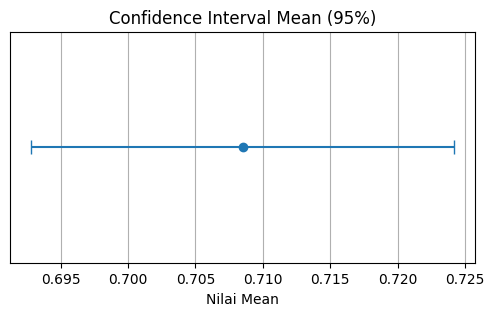

In [34]:
# Visualisasi Confidence Interval Mean
import matplotlib.pyplot as plt

plt.figure(figsize=(6,3))

plt.errorbar(
    theta_hat,
    0,
    xerr=[[theta_hat-ci_mean[0]], [ci_mean[1]-theta_hat]],
    fmt='o',
    capsize=5
)

plt.yticks([])
plt.xlabel("Nilai Mean")
plt.title("Confidence Interval Mean (95%)")
plt.grid(True)

plt.show()

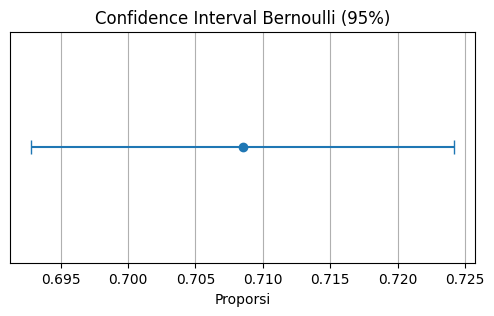

In [35]:
# Visualisasi Confidence Interval Bernoulli

plt.figure(figsize=(6,3))

plt.errorbar(
    theta_hat,
    0,
    xerr=[[theta_hat-ci_bernoulli_result[0]], [ci_bernoulli_result[1]-theta_hat]],
    fmt='o',
    capsize=5
)

plt.yticks([])
plt.xlabel("Proporsi")
plt.title("Confidence Interval Bernoulli (95%)")
plt.grid(True)

plt.show()

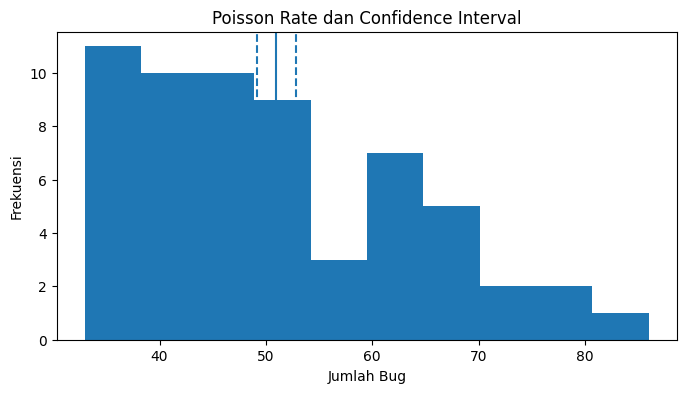

In [36]:
# Visualisasi Confidence Interval Poisson

plt.figure(figsize=(8,4))

plt.hist(data_bug_count, bins=10)

plt.axvline(lambda_hat)
plt.axvline(ci_pois[0], linestyle='--')
plt.axvline(ci_pois[1], linestyle='--')

plt.title("Poisson Rate dan Confidence Interval")
plt.xlabel("Jumlah Bug")
plt.ylabel("Frekuensi")

plt.show()


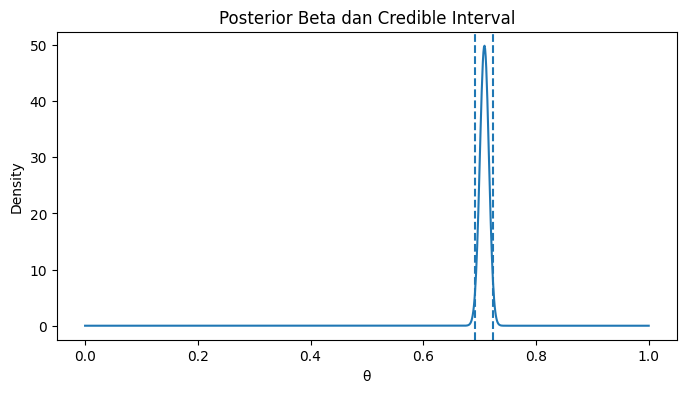

In [37]:
# Visualisasi Bayesian Credible Interval

from scipy.stats import beta
import numpy as np

x = np.linspace(0,1,1000)

posterior = beta.pdf(
    x,
    alpha_post,
    beta_post
)

plt.figure(figsize=(8,4))

plt.plot(x, posterior)

plt.axvline(ci_bayes[0], linestyle='--')
plt.axvline(ci_bayes[1], linestyle='--')

plt.title("Posterior Beta dan Credible Interval")
plt.xlabel("θ")
plt.ylabel("Density")

plt.show()

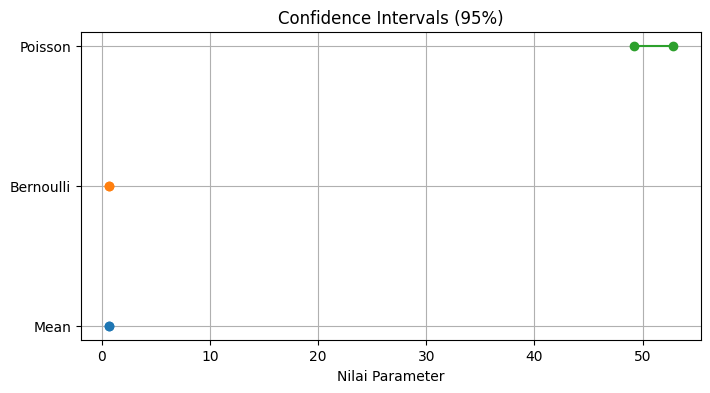

In [38]:
# Visualisasi Confidence Interval 
# Garis menunjukan rentang dan titik kiri sebagai batas bawah, titik kanan sebagai batas atas

import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

methods = [
    "Mean",
    "Bernoulli",
    "Poisson"
]

estimate = [
    theta_hat,
    theta_hat,
    lambda_hat
]

lower = [
    ci_mean[0],
    ci_bernoulli_result[0],
    ci_pois[0]
]

upper = [
    ci_mean[1],
    ci_bernoulli_result[1],
    ci_pois[1]
]

for i in range(len(methods)):
    plt.plot(
        [lower[i], upper[i]],
        [i, i],
        marker='o'
    )

plt.yticks(range(len(methods)), methods)

plt.xlabel("Nilai Parameter")
plt.title("Confidence Intervals (95%)")
plt.grid(True)

plt.show()

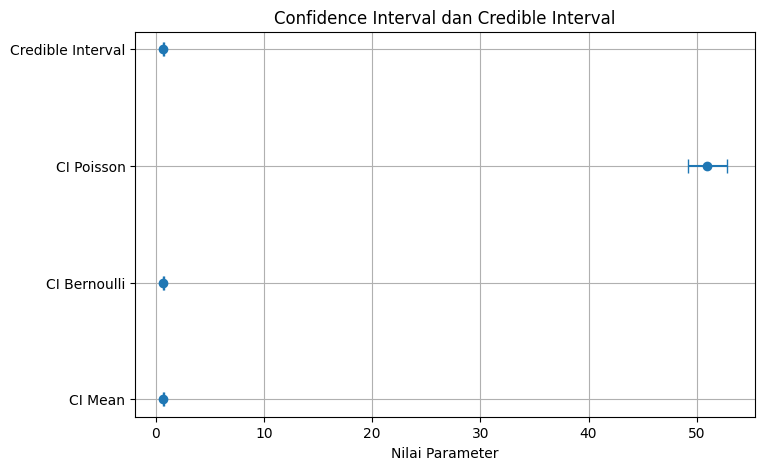

In [39]:
# Visualisasi Perbandingan

import matplotlib.pyplot as plt
import numpy as np

methods = [
"CI Mean",
"CI Bernoulli",
"CI Poisson",
"Credible Interval"
]

lower = [
ci_mean[0],
ci_bernoulli_result[0],
ci_pois[0],
ci_bayes[0]
]

upper = [
ci_mean[1],
ci_bernoulli_result[1],
ci_pois[1],
ci_bayes[1]
]

center = [(l + u) / 2 for l, u in zip(lower, upper)]
error = [(u - l) / 2 for l, u in zip(lower, upper)]

plt.figure(figsize=(8,5))

plt.errorbar(
center,
np.arange(len(methods)),
xerr=error,
fmt='o',
capsize=5
)

plt.yticks(np.arange(len(methods)), methods)
plt.xlabel("Nilai Parameter")
plt.title("Confidence Interval dan Credible Interval")
plt.grid(True)

plt.show()

## Kesimpulan

Berdasarkan proses statistical inference yang dilakukan menggunakan hasil estimasi parameter dari Notebook Estimator, dapat disimpulakan bahwa interval estimasi adalah parameter penting dalam data. Confidence Interval digunakan untuk menentukan rentang nilai parameter populasi yang mungkin berdasarkan data sampel dengan tingkat kepercayaan 95%.

- Confidence Interval Mean menunjukkan rentang estimasi parameter rata-rata.
- Confidence Interval Bernoulli menunjukkan rentang proporsi keberhasilan sistem.
- Confidence Interval Poisson menunjukkan rentang estimasi rata-rata jumlah bug.
- Bayesian Credible Interval menunjukkan rentang probabilitas parameter berdasarkan posterior Beta(2288, 942).


## Summary cell To The Next Layer
Pada Notebook D, analisis akan beralih ke pengujian hipotesis (Hypothesis Testing) menggunakan dataset bulanan (monthly). Tujuannya untuk menguji hipotesis mengenai data dan menentukan keputusan menolak hipotesis nol berdasarkan nilai p-value.